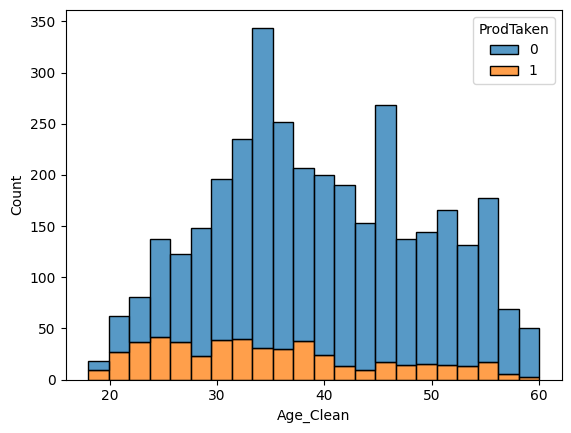

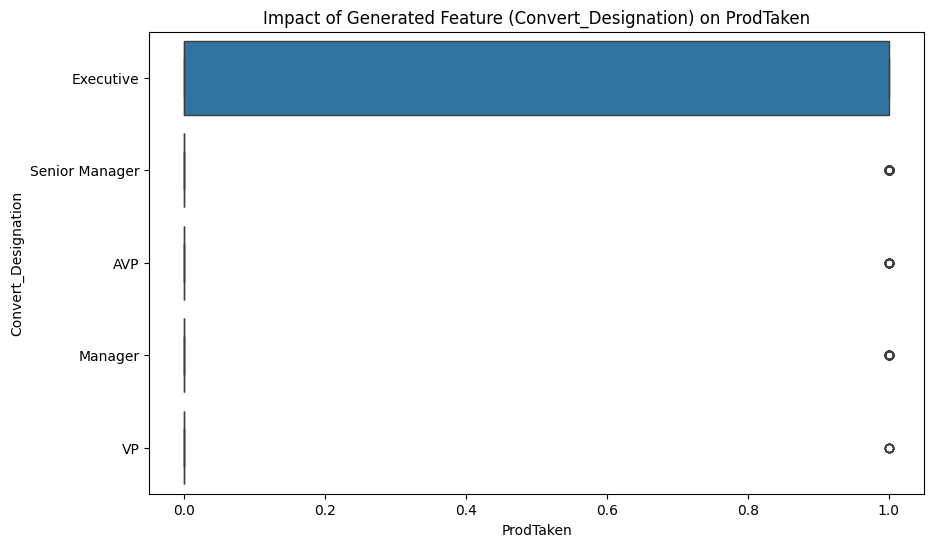

In [ ]:
# 1. 必要なモジュールのインポート
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Notebookからsrcディレクトリを参照できるようにパスを追加
sys.path.append('../')

from src.preprocessing.cleaning import run_cleaning
from src.preprocessing.imputation import MissingValueImputer

# 2. データの読み込み
df_train_raw = pd.read_csv("../data/raw/train.csv")

# 3. モジュールを使用した前処理・補完の実行（コピペではなく呼び出し）
df_train_clean = run_cleaning(df_train_raw)
imputer = MissingValueImputer()
df_train_imputed = imputer.fit_transform(df_train_clean)

# 4. 補完後データの可視化と考察
sns.histplot(data=df_train_imputed, x='Age_Clean', hue='ProdTaken', multiple='stack')
plt.show()

# 5. 特徴量エンジニアリングモジュールのインポート
from src.features.basic_features import FeatureEngineer
from src.features.categorical_features import CategoricalEncoder
from src.features.advanced_features import PostEncodingEngineer

# 基本特徴量の生成
fe = FeatureEngineer()
df_train_fe = fe.fit_transform(df_train_imputed)

# カテゴリ変数のエンコーディング
te_cols = ["Product_Clean", "Convert_Designation", "MaritalStatus"]
encoder = CategoricalEncoder(te_columns=te_cols, target_col="ProdTaken")
df_train_encoded = encoder.fit_transform(df_train_fe)

# 高度な特徴量生成（集約・交互作用など）
post_fe = PostEncodingEngineer()
df_train_final = post_fe.fit_transform(df_train_encoded)

# 6. 生成した特徴量の有効性検証（可視化の例）
plt.figure(figsize=(10, 6))
# ※以下は例として、PostEncodingEngineerで作られた仮の特徴量 'Convert_Designation' を可視化
sns.boxplot(data=df_train_final, x='ProdTaken', y='Convert_Designation')
plt.title('Impact of Generated Feature (Convert_Designation) on ProdTaken')
plt.show()

In [12]:
df_train_clean["Convert_Designation"].value_counts()

Convert_Designation
Executive         1150
Manager           1055
Senior Manager     854
AVP                311
VP                 119
Name: count, dtype: int64